## Libraries Used

In [1]:
from pathlib import Path

import evaluate
import joblib
import pandas as pd
import seaborn as sns
import transformers
from datasets import load_dataset
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from transformers.trainer_utils import EvalPrediction

transformers.logging.set_verbosity_error()

W0913 20:26:23.422000 21468 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


## Setup...

Setup is here for setting up directories/paths.

In [2]:
import sys

is_colab = "google.colab" in sys.modules
if is_colab:
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    OUT_DIR = "./drive/MyDrive/Colab Notebooks/ModernBert"
else:
    OUT_DIR = "./ModernBert"

# instantiate the model
NAME = "answerdotai/ModernBERT-base"

Then below is the framework for what I used for the training. This includes the model, tokenizer, and trainer

In [3]:
def get_frozen_model():
    model = transformers.AutoModelForSequenceClassification.from_pretrained(
        NAME,
        dtype="auto",
        num_labels=2,
    )
    for param in model.base_model.parameters():
        param.requires_grad_(False)
    return model


# set up the dataset and dataset loading
tokenizer = transformers.AutoTokenizer.from_pretrained(NAME)
ds_raw = load_dataset("stanfordnlp/sst2")

# tokenize the dataset entries
ds = ds_raw.map(
    lambda item: tokenizer(
        item["sentence"],
        truncation=True,
        max_length=512,
    )
)

# batch collator
collator = transformers.DataCollatorWithPadding(tokenizer)

# accuracy setup
accuracy = evaluate.load("accuracy")


def calc_accuracy(p: EvalPrediction) -> dict:
    return accuracy.compute(
        predictions=p.predictions.argmax(axis=-1),  # type: ignore
        references=p.label_ids,
    )


def get_trainer(model, type: str):
    training_args = transformers.TrainingArguments(
        output_dir=f"{OUT_DIR}/{type}",
        num_train_epochs=4,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        bf16=True,
        learning_rate=2e-5,
        eval_strategy="steps",
        eval_steps=1000,
        save_strategy="steps",
        save_steps=1000,
        load_best_model_at_end=True,
        disable_tqdm=False,
    )

    return transformers.Trainer(
        model,
        args=training_args,
        train_dataset=ds["train"],
        eval_dataset=ds["validation"],
        compute_metrics=calc_accuracy,
        processing_class=tokenizer,
        data_collator=collator,
    )

Below is what I used to measure accuracy over the training period; I take each checkpointed model and test the accuracy over the validation set and the first 100-ish examples of the training set.

In [5]:
mem = joblib.Memory(
    f"{OUT_DIR}/eval"
)  # cache since training accuracy takes a long time to compute


@mem.cache(verbose=0)
def get_checkpoints_accuracy(name, step):
    ckpt_path = f"{OUT_DIR}/{name}/checkpoint-{step}"

    if name == "lora":
        base_model = (
            transformers.AutoModelForSequenceClassification.from_pretrained(
                NAME,
                num_labels=2,
            )
        )
        checkpointed_model = PeftModel.from_pretrained(base_model, ckpt_path)
    else:
        checkpointed_model = (
            transformers.AutoModelForSequenceClassification.from_pretrained(
                ckpt_path,
                num_labels=2,
            )
        )
    dummy_trainer = get_trainer(checkpointed_model, name)

    train_accuracy = dummy_trainer.evaluate(
        ds["train"].select(range(len(ds["validation"])))
    )["eval_accuracy"]
    eval_accuracy = dummy_trainer.evaluate(ds["validation"])["eval_accuracy"]

    return {
        "step": step,
        "train_accuracy": train_accuracy,
        "eval_accuracy": eval_accuracy,
    }

## Head Tuning

### Training

In [4]:
model = get_frozen_model()
trainer = get_trainer(model, "head_tuning")
trainer.train(resume_from_checkpoint=True)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss


TrainOutput(global_step=16840, training_loss=0.0, metrics={'train_runtime': 0.0029, 'train_samples_per_second': 91544091.419, 'train_steps_per_second': 5722440.198, 'total_flos': 3511377825746616.0, 'train_loss': 0.0, 'epoch': 4.0})

### Accuracy Plot

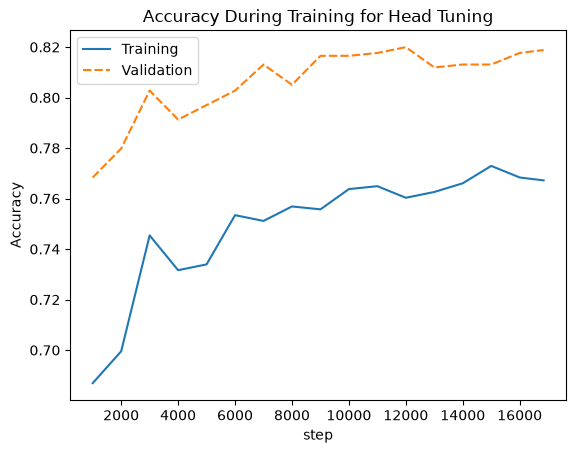

In [7]:
ht_acc = []
for step in [*[s for s in range(1000, 17000, 1000)], 16840]:
    ht_acc.append(get_checkpoints_accuracy('head_tuning', step))
ht_acc_df = pd.DataFrame(ht_acc).set_index('step')

ax = sns.lineplot(ht_acc_df)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy During Training for Head Tuning")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Training', 'Validation']);

## LoRA

Let's see how many trainable params the head tuning model had...

In [8]:
trainer.get_num_trainable_parameters()

592130

Now let's see what we can get with LoRA. This will have low-rank updates for the classifier and head (so same area as in 4.1), but also for the attention matrices throughout the model.

In [9]:
lora_config = LoraConfig(
    r=8,
    task_type=TaskType.SEQ_CLS,
    target_modules=['Wqkv', 'classifier', 'head.dense']
)
lora_model = get_peft_model(get_frozen_model(), lora_config)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

Then the number of trainable parameters for this is:

In [10]:
lora_model.get_nb_trainable_parameters()[0]

554498

So we have about 50000 (~10%) fewer parameters - that's in the same ballpark.

Now let's train...

In [11]:
lora_trainer = get_trainer(lora_model, 'lora')
lora_trainer.train(resume_from_checkpoint=True)

Step,Training Loss,Validation Loss


TrainOutput(global_step=16840, training_loss=0.0, metrics={'train_runtime': 0.0011, 'train_samples_per_second': 242421952.453, 'train_steps_per_second': 15153846.677, 'total_flos': 3528930888009072.0, 'train_loss': 0.0, 'epoch': 4.0})

### Accuracy Plot

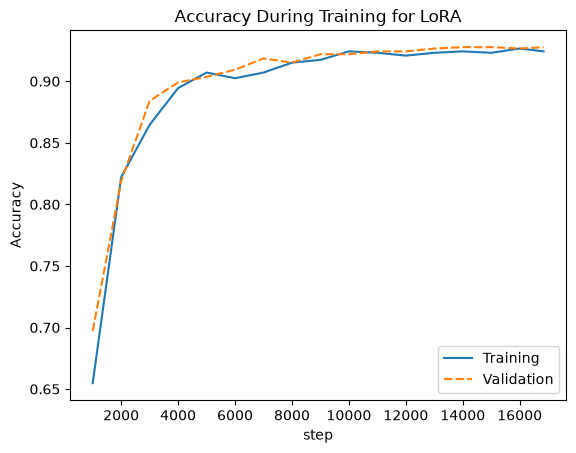

In [17]:
lora_acc = []
for step in [*[1000 * (i + 1) for i in range(16)], 16840]:
    lora_acc.append(get_checkpoints_accuracy('lora', step))
lora_acc_df = pd.DataFrame(lora_acc).set_index('step')

ax = sns.lineplot(lora_acc_df)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy During Training for LoRA")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Training', 'Validation']);

## Top Validation Accuracy

Below is the table for the top validation accuracy for each approach; it is also copied to the typeset hw.

In [16]:
table1 = pd.DataFrame([
    {
        "Approach": "Head Tuning",
        "Accuracy (validation)": ht_acc_df["eval_accuracy"].max(),
    },
    {
        "Approach": "LoRA",
        "Accuracy (validation)": lora_acc_df["eval_accuracy"].max(),
    }
])

table_str = table1.style.hide().format()
table_str

Approach,Accuracy (validation)
Head Tuning,0.819954
LoRA,0.927752
